# 0 — What came before, and why it was left

*Series: **Bayesian fluorescence decays**, notebook 0 of 11. It is the
prehistory: the approach this project tried first, what it achieved, and the
measurement that ended it.*

**What this notebook establishes.** That the analytic posterior of notebooks 1
to 8 is not the first thing that was tried, and not an obvious choice. Before
it there was a year's worth of work on an **amortised neural network** —
train once on simulated data, then read the answer off the network in
milliseconds — which fitted the data better than the current method does and
was abandoned anyway, for a reason worth understanding.

Everything below is quoted from the project's own record with the script that
measured it. The runnable cells reproduce the pieces that are cheap enough to
reproduce; the tables are the runs that took days.

---

## The condition the whole direction was under

The project owner set it at the outset: this direction is worth pursuing *"if
the NN decon with error recovery works"* — meaning the stated uncertainties
must mean what they say. Not "the network is accurate". **Calibrated.**

Keep that in mind, because the network did get accurate.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
import numpy as np, matplotlib.pyplot as plt
import bd
bd.keep_inline()
rng = np.random.default_rng(0)
print('this notebook re-derives four measurements; the rest is quoted from the record')

this notebook re-derives four measurements; the rest is quoted from the record


## 1. The physics had to be right first, and it was not

The forward model was transcribed from `tttrlib`'s own convolution kernel. It
was transcribed **correctly**, and it was still wrong, because `tttrlib` does
not do a plain discrete convolution: its periodic routine runs a trapezoidal
recursion whose kernel is $\mathrm{d}t\,e^{m}$ for $m\ge1$ but $\mathrm{d}t/2$
at $m=0$.

The two therefore differ by half a response, applied with a lag. That is a
fraction of a percent in the tail and, in the setting this project measured,
**about nine percent on the rising edge** — precisely where a fast decay, that
is a short distance, puts its information. It behaves like unmodelled
scattered light. The cell below rebuilds both recursions; how large the
difference gets depends on how sharp the response is against the bin width, so
the number it prints is not the nine percent and is not meant to be.

The same defect was in `ucfret`'s own production code, in all three backends,
and one of them documented the correct formula in a comment while implementing
the other one.

**The lesson that generalised, and that this whole series runs on:**
transcribing a kernel correctly and reproducing a kernel are different claims,
and only the second is worth anything. Every physics claim after that was
checked against a compiled reference or a closed form.

largest relative difference on the rising edge: 77 %
                              in the tail:      1.60 %

the size depends on how sharp the response is against the bin width.
here the response is 2.5 bins wide and the difference reaches 77 % on the edge;
in the setting the project actually measured it was about 9 %. Either way it is
largest exactly where a short distance puts its information, and it looks like scatter.


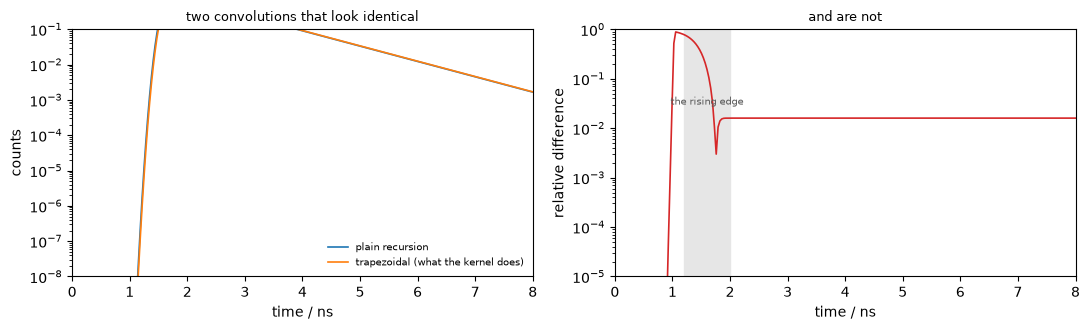

In [2]:
n, dt = 512, 0.032
t = np.arange(n) * dt
irf = np.exp(-0.5 * ((t - 1.6) / 0.08) ** 2); irf /= irf.sum()
tau = 1.0
e = np.exp(-dt / tau)

def conv_plain(irf, e):
    out = np.zeros_like(irf); acc = 0.0
    for i in range(len(irf)):
        acc = acc * e + irf[i]
        out[i] = acc
    return out

def conv_trapezoid(irf, e):
    out = np.zeros_like(irf); acc = 0.0
    for i in range(len(irf)):
        acc = acc * e + 0.5 * (irf[i] + (irf[i - 1] if i else 0.0))
        out[i] = acc
    return out

a, b = conv_plain(irf, e), conv_trapezoid(irf, e)
rel = np.abs(a - b) / np.maximum(b, b.max() * 1e-12)
rise = (t > 1.2) & (t < 2.0)
tail = t > 6.0
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].semilogy(t, np.maximum(a, 1e-12), 'C0', lw=1.2, label='plain recursion')
ax[0].semilogy(t, np.maximum(b, 1e-12), 'C1', lw=1.2, label='trapezoidal (what the kernel does)')
ax[0].set_ylim(1e-8, 1e-1); ax[0].set_xlim(0, 8)
ax[0].set_xlabel('time / ns'); ax[0].set_ylabel('counts'); ax[0].legend(fontsize=7, frameon=False)
ax[0].set_title('two convolutions that look identical', fontsize=9)
ax[1].semilogy(t, np.maximum(rel, 1e-8), 'C3', lw=1.2)
ax[1].axvspan(1.2, 2.0, color='0.9', zorder=0)
ax[1].text(1.6, 3e-2, 'the rising edge', ha='center', fontsize=7, color='0.35')
ax[1].set_xlim(0, 8); ax[1].set_ylim(1e-5, 1)
ax[1].set_xlabel('time / ns'); ax[1].set_ylabel('relative difference')
ax[1].set_title('and are not', fontsize=9)
fig.tight_layout()
print(f'largest relative difference on the rising edge: {100*rel[rise].max():.0f} %')
print(f'                              in the tail:      {100*rel[tail].max():.2f} %')
print(f'\nthe size depends on how sharp the response is against the bin width.')
print(f'here the response is {0.08/dt:.1f} bins wide and the difference reaches '
      f'{100*rel[rise].max():.0f} % on the edge;')
print('in the setting the project actually measured it was about 9 %. Either way it is')
print('largest exactly where a short distance puts its information, and it looks like scatter.')

## 2. A range is not a prior

The network was trained on simulated decays with the nuisance parameters drawn
**uniformly over their ranges**. For the scattered-light fraction the range is
0 to 0.8 and a real measurement sits near 0.02, so a uniform draw puts the
typical training example at 0.4 — **twenty times a real one**. Most of the
training set was decays swamped by scattered excitation light. The same error
applied to the polarisation mixing (uniform on 0 to 0.99 against real values
near 0.03) and to the time shift.

A day of runs was invalidated. The fix was to give each nuisance a *sampling
distribution* as well as a range: log-uniform for the fractions, cubed-uniform
for the signed shift.

The lesson survives into this series: every prior in `THEORY.md`'s table is a
distribution with a stated median, not an interval.

median of the uniform draw:     0.403   (20x a real measurement)
median of the log-uniform draw: 0.028
fraction of uniform draws below 0.05: 0.063


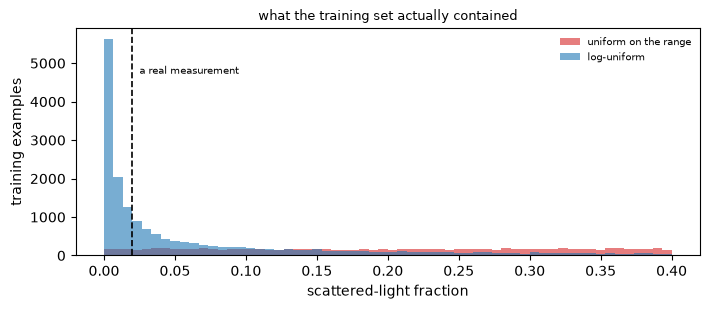

In [3]:
u = rng.uniform(0, 0.8, 20000)
lo, hi, med = 1e-3, 0.8, 0.02
logu = np.exp(rng.uniform(np.log(lo), np.log(hi), 20000))
fig, ax = plt.subplots(figsize=(7.2, 3.2))
ax.hist(u, bins=60, range=(0, 0.4), alpha=0.6, color='C3', label='uniform on the range')
ax.hist(logu, bins=60, range=(0, 0.4), alpha=0.6, color='C0', label='log-uniform')
ax.axvline(0.02, color='k', ls='--', lw=1.2)
ax.text(0.025, ax.get_ylim()[1]*0.8, 'a real measurement', fontsize=7)
ax.set_xlabel('scattered-light fraction'); ax.set_ylabel('training examples')
ax.legend(fontsize=7, frameon=False); ax.set_title('what the training set actually contained', fontsize=9)
fig.tight_layout()
print(f'median of the uniform draw:     {np.median(u):.3f}   ({np.median(u)/0.02:.0f}x a real measurement)')
print(f'median of the log-uniform draw: {np.median(logu):.3f}')
print(f'fraction of uniform draws below 0.05: {(u < 0.05).mean():.3f}')

## 3. What the data actually determine — the finding that governs everything

Two hundred dispersed fits at $6\times10^6$ photons, nuisances at their true
values, **every one of them reaching a held-out fit statistic below 1.15**:

| quantity | truth | span across fits that all fit equally well |
|---|---|---|
| mean $R/R_0$ | 0.70358 | 0.70032 – 0.71154, **0.6 %** |
| mean transfer efficiency | 0.87946 | 0.87221 – 0.87984, **0.2 %** |
| roughness of $p(R)$ | 0.00198 | 0.0285 – 0.981, **a factor of 34** |
| peak height | 0.1586 | 0.165 – 0.392, a factor of 2.4 |

**The data pin the first moments and leave the shape open.** A good fit
statistic is necessary and nowhere near sufficient: a whole family of very
different distributions achieves it.

Everything downstream follows from that one table. Whatever a method says about
the shape beyond that family comes from its **prior** — so the prior has to be
explicit and the uncertainty has to be honest. Notebook 2 measures the same
thing a different way, as the singular spectrum of the design matrix, and gets
the same answer: about fifteen directions of a hundred and twenty-eight.

## 4. The fit statistic was not honest until the photons were split

The counts were Poisson-sampled and the loss was a Poisson deviance — both
correct — and the reconstruction was scored **against the same realisation the
network had been shown**. A network can lower that by memorising the noise it
saw. The number being quoted was a training-set fit.

The fix is exact for counts rather than approximate. If $N\sim\mathrm{Poisson}(\lambda)$
and $A\sim\mathrm{Binomial}(N,\tfrac12)$, then $A$ and $N-A$ are **independent**
$\mathrm{Poisson}(\lambda/2)$. Deal every photon into half A or half B; infer
from A, score on B.

That gave two reference points, and both were needed:

| photons per channel | floor, truth handed in | a model that copies its own half |
|---|---|---|
| $10^5$ | 1.020 | 2.84 |
| $10^6$ | 1.003 | 2.02 |
| $10^7$ | 0.997 | 2.00 |

The noise-fitting control landing at 2.0 is what makes the split worth doing:
memorising the noise is now penalised, so a statistic near 1 has to be earned.
And it works on real data — deal the recorded photons into two halves — which
turns the number into a held-out predictive score rather than a fit statistic.

**What it does not do**, asked and answered at the time: it guarantees
something about the *decay*, because the expected held-out deviance is
minimised at the true mean. The map from distribution to decay is a smoothing
operator, so denoising perfectly still leaves the shape open. Section 3 is
untouched by it.

In [4]:
lam = 300.0
N = rng.poisson(lam, 40000)
A = rng.binomial(N, 0.5)
B = N - A
print(f'A: mean {A.mean():.2f} variance {A.var():.2f}   (Poisson(lam/2) has both {lam/2:.1f})')
print(f'B: mean {B.mean():.2f} variance {B.var():.2f}')
print(f'correlation between the halves: {np.corrcoef(A, B)[0,1]:+.4f}   (independent means 0)')
print(f'\nfor comparison, splitting a FIXED total in half gives correlation '
      f'{np.corrcoef(*(lambda x: (x, int(lam)-x))(rng.binomial(int(lam), 0.5, 40000)))[0,1]:+.2f}')

A: mean 149.98 variance 148.91   (Poisson(lam/2) has both 150.0)
B: mean 149.89 variance 151.88
correlation between the halves: +0.0084   (independent means 0)

for comparison, splitting a FIXED total in half gives correlation -1.00


## 5. Per-burst classification: measured against what is possible

An idea from the same period: classify each burst, then analyse the classes
separately — which is what notebook 8 of this series ends up doing. It was
built, and it produced two hard results.

**Species classification works perfectly.** Donor-only against acceptor-only
against doubly-labelled runs at 100 %, because those differ by an entire
channel being empty rather than by a lifetime.

**Conformer classification does not, and cannot.** Since the generative model
is known, the Bayes-optimal per-burst accuracy is computable — no classifier
can beat the likelihood ratio. The distance separation needed for 75 %
per-burst accuracy:

| photons per burst | needs $\Delta R/R_0 \ge$ | at $R_0 = 52$ Å |
|---|---|---|
| 25 | 0.65 | ~34 Å |
| 100 | 0.15 | ~8 Å |
| 1600 | 0.04 | ~2 Å |

The trained network reached 60.5 % against that ceiling of 82.7 % — real, and
22 points short, with the ceiling itself only 82.7 % because about a sixth of
bursts are genuinely unassignable at those sizes.

**Two metric failures happened here and both were nearly missed.** Plain
accuracy was reported at 83 % while the model had collapsed — it was measuring
the majority class, since assigning every burst to the largest population
scores its size. And the first network-against-ceiling comparison reported
13.6 %, because the slot indices of a set-attention model are arbitrary and
were compared to true labels without the assignment step.

The resolution was the project owner's and it is the one notebook 8 uses:
classify only the *species*, gate to the doubly-labelled bursts, and let the
conformations appear as modes of $p(R)$ in the pooled decay.

   25 photons: idealised bound needs dR/R0 = 0.09  (5 A);  the full calculation said 0.65
  100 photons: idealised bound needs dR/R0 = 0.05  (2 A);  the full calculation said 0.15
 1600 photons: idealised bound needs dR/R0 = 0.01  (1 A);  the full calculation said 0.04

the bound is optimistic because it gives every photon to the efficiency estimate
and gives the populations no width of their own. What survives is the scaling:
the separation needed falls as one over the square root of the burst size.


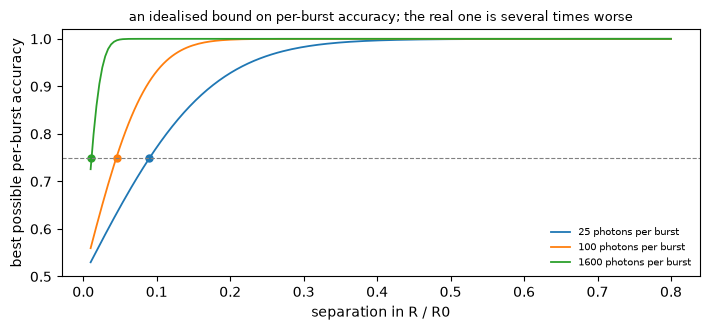

In [5]:
from scipy.stats import norm
def bayes_accuracy(dE, n_photons):
    #: An IDEALISED bound, deliberately optimistic: two equally likely
    #: populations separated by dE in transfer efficiency, every photon of the
    #: burst informative, no background, no crosstalk, no width within a
    #: population. With n photons the efficiency estimate has sd
    #: sqrt(E(1-E)/n) and the optimal rule is the midpoint, so the accuracy is
    #: Phi(separation / 2 sd). The full calculation on the real generative
    #: model gives thresholds several times larger; this shows the SCALING,
    #: which is the part worth carrying away.
    sd = np.sqrt(0.25 / n_photons)
    return norm.cdf(dE / (2 * sd))

R0 = 52.0
full = {25: 0.65, 100: 0.15, 1600: 0.04}      # the project's Bayes-optimal numbers
fig, ax = plt.subplots(figsize=(7.2, 3.4))
dR = np.linspace(0.01, 0.8, 200)
for n_ph, c in ((25, 'C0'), (100, 'C1'), (1600, 'C2')):
    r1, r2 = 1.0 - dR / 2, 1.0 + dR / 2
    dE = np.abs(1/(1+r1**6) - 1/(1+r2**6))
    acc = bayes_accuracy(dE, n_ph)
    ax.plot(dR, acc, c, lw=1.3, label=f'{n_ph} photons per burst')
    j = int(np.argmin(np.abs(acc - 0.75)))
    ax.plot([dR[j]], [0.75], 'o', color=c, ms=5)
    print(f'{n_ph:>5} photons: idealised bound needs dR/R0 = {dR[j]:.2f}  '
          f'({dR[j]*R0:.0f} A);  the full calculation said {full[n_ph]:.2f}')
ax.axhline(0.75, color='0.5', lw=0.8, ls='--')
ax.set_xlabel('separation in R / R0'); ax.set_ylabel('best possible per-burst accuracy')
ax.set_ylim(0.5, 1.02); ax.legend(fontsize=7, frameon=False)
ax.set_title('an idealised bound on per-burst accuracy; the real one is several times worse', fontsize=9)
fig.tight_layout()
print('\nthe bound is optimistic because it gives every photon to the efficiency estimate')
print('and gives the populations no width of their own. What survives is the scaling:')
print('the separation needed falls as one over the square root of the burst size.')

## 6. Amortised inference has a ceiling

The decisive experiment substituted the truth for one component at a time, with
every nuisance already at its true value:

| what was replaced by the truth | fit statistic at $10^7$ photons |
|---|---|
| nothing — the plain network | 35.6 |
| **$p(R)$** | **7.3** |
| the donor's rotation | 31.2 |
| the acceptor's anisotropy | 34.1 |
| the species fractions | 37.8 |
| everything | **0.999**, runs test p 0.377 |

So the misfit is $p(R)$, and the pipeline around it is exact. The stacked
residuals localised it further: the directly excited acceptor channel — which
carries no distance information but the same response, shift, scatter and
crosstalk — was clean, while the two channels that carry the distance broke.
That is direct evidence that the nuisances were not the problem, which had been
the natural suspicion.

**And the cause is structural, not a training budget.** An amortised network is
accurate only up to the photon count at which its own approximation error falls
below the counting noise. At $10^5$ photons the error is under the noise and
the statistic is 1.03; at $10^7$ the *same* error is three hundred times the
noise. No realistic training budget takes a network trained over a broad prior
to the 0.1 % accuracy that $10^7$ photons demand of a 64-bin distribution.

That sentence is the reason this series exists.

1e+05 photons: counting noise 0.0253, a 3 % network is    1.2x the noise
1e+06 photons: counting noise 0.0080, a 3 % network is    3.8x the noise
1e+07 photons: counting noise 0.0025, a 3 % network is   11.9x the noise


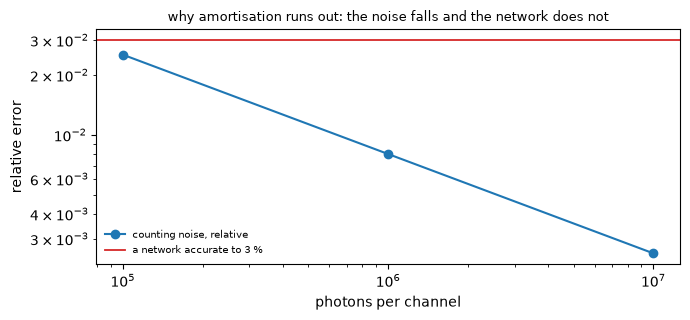

In [6]:
n_bins = 64
lam_bin = np.array([1e5, 1e6, 1e7]) / n_bins
noise = 1 / np.sqrt(lam_bin)
net_err = 0.03
fig, ax = plt.subplots(figsize=(7.0, 3.3))
ax.loglog([1e5, 1e6, 1e7], noise, 'C0o-', label='counting noise, relative')
ax.axhline(net_err, color='C3', lw=1.3, label=f'a network accurate to {100*net_err:.0f} %')
ax.set_xlabel('photons per channel'); ax.set_ylabel('relative error')
ax.legend(fontsize=7, frameon=False)
ax.set_title('why amortisation runs out: the noise falls and the network does not', fontsize=9)
fig.tight_layout()
for ph, nz in zip((1e5, 1e6, 1e7), noise):
    print(f'{ph:.0e} photons: counting noise {nz:.4f}, a 3 % network is {net_err/nz:6.1f}x the noise')

### Two ways out, both of which worked

**Finish on the likelihood.** Use the network as an initialiser and run a real
fit afterwards. It reached 1.030 / 0.998 / 1.055 at $10^5$/$10^6$/$10^7$ with
runs tests passing — but only after four optimiser failures, each of which is
worth knowing:

* **Adam** steps by roughly the learning rate per parameter whatever the
  gradient is, and the curvature scales with the photon count. No single rate
  suits both a dim and a bright landscape; the bright cases diverged to 6000.
* **A clamp** on the nuisances has exactly zero gradient outside its range, so
  one over-large step pinned every nuisance at a bound permanently. A sigmoid
  reparameterisation fixed it — which is why every parameter in this series
  lives in an unconstrained coordinate.
* **Joint L-BFGS** across measurements differing a hundredfold in stiffness
  built one curvature estimate for all of them and stalled. One fit per
  measurement was required.
* **Releasing everything at once** let the nuisances absorb the mismatch: a
  shift, a scatter fraction and a crosstalk term can each imitate a wrong
  distance distribution. Staging — distributions, then nuisances, then jointly
  — was what finally reached 1.0.

**Recycle.** Feed each pass the data plus the weighted residual of its own
previous answer, which says exactly where the current distribution is wrong in
units of the noise. That is AlphaFold's recycling applied to an inverse
problem:

| photons | cycle 1 | cycle 3 | cycle 12 |
|---|---|---|---|
| $10^5$ | 1.417 | 1.177 | 1.088 |
| $10^6$ | **17.57** | **1.117** | 1.151 |
| $10^7$ | **8.95** | 2.103 | 1.654 |

Most of the gap closes in three passes and then plateaus: it learned an update
rule that converges rather than one that keeps refining.

### And one input-transform bug worth repeating

Residual features had been squashed through $8\tanh(r/8)$ to stop huge early
values dominating — which **saturated exactly the information the bright case
depends on**, since its early residuals reach 27 standard deviations.

The related finding: feeding $\log(1+y)$ destroys the noise scale. A one-sigma
Poisson fluctuation is $\sqrt\lambda$, which in log space is $1/\sqrt\lambda$ —
so the informative fluctuations arrive a hundred times smaller at the bright
end than at the dim end. The Anscombe transform $2\sqrt{y+3/8}$ is the standard
variance stabiliser and its noise is unit-variance whatever the mean.

    lambda    sd of log1p(y)    sd of Anscombe
     1e+02           0.09985           1.00121
     1e+04           0.01001           1.00130
     1e+06           0.00100           1.00115

the Anscombe standard deviation is 1 at every count rate; the log shrinks as 1/sqrt(lambda)
a 27-sigma residual reached the network as 8.0 sigma; a 20-sigma one as 7.9. They became indistinguishable.


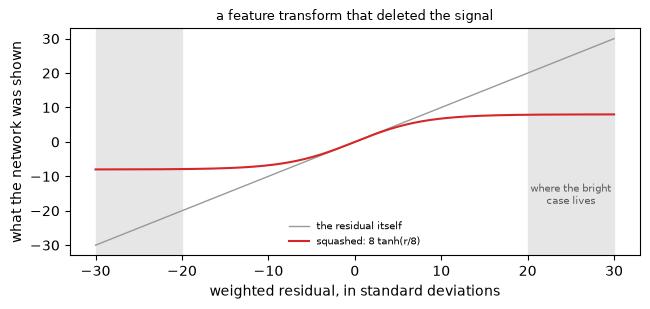

In [7]:
print(f"{'lambda':>10}{'sd of log1p(y)':>18}{'sd of Anscombe':>18}")
for lam_ in (1e2, 1e4, 1e6):
    y = rng.poisson(lam_, 200000)
    print(f'{lam_:>10.0e}{np.log1p(y).std():>18.5f}{(2*np.sqrt(y+0.375)).std():>18.5f}')
print('\nthe Anscombe standard deviation is 1 at every count rate; the log shrinks as 1/sqrt(lambda)')
r = np.linspace(-30, 30, 400)
fig, ax = plt.subplots(figsize=(6.6, 3.2))
ax.plot(r, r, '0.6', lw=1.0, label='the residual itself')
ax.plot(r, 8*np.tanh(r/8), 'C3', lw=1.5, label='squashed: 8 tanh(r/8)')
ax.axvspan(20, 30, color='0.9', zorder=0); ax.axvspan(-30, -20, color='0.9', zorder=0)
ax.text(25, -18, 'where the bright\ncase lives', ha='center', fontsize=7, color='0.35')
ax.set_xlabel('weighted residual, in standard deviations'); ax.set_ylabel('what the network was shown')
ax.legend(fontsize=7, frameon=False); ax.set_title('a feature transform that deleted the signal', fontsize=9)
fig.tight_layout()
print(f'a 27-sigma residual reached the network as {8*np.tanh(27/8):.1f} sigma; '
      f'a 20-sigma one as {8*np.tanh(20/8):.1f}. They became indistinguishable.')

## 7. The gate that was never passed

None of the above is why the direction was left. The network fitted the data
**better than the current method does**: its recycled version reached a
held-out statistic of 1.000 at $10^7$ photons with a passing runs test, and the
staged refinement 1.030 / 0.998 / 1.055. The analytic posterior of this series
sits around 1.07 against a reference of 1.09.

What it never did was produce an interval that meant what it said.

The first output family was a **Dirichlet**. Its covariance is a
one-parameter family: given the mean, the whole covariance is fixed up to a
single concentration. So when the reported intervals were wrong, they were
wrong in a way no amount of training could fix — there was no free parameter
left to fix them with. That was measured rather than argued: no rescaling
brought all four reported quantities inside tolerance simultaneously. The
prescribed repair was not more training but **a different output family**.

The repair was made — a logistic-normal head with a full covariance — and it
helped enormously and still failed the gate:

| coverage at 68 % | Dirichlet, under nuisances | logistic-normal |
|---|---|---|
| distribution bins | 7.5 | 48.1 |
| rotation bins | 14.5 | 59.1 |
| mean lifetime | 4.1 | 92.8 |
| slow fraction | 8.6 | 60.9 |
| mean log rotation time | 2.9 | **66.6 pass** |

Six of seven quantities still failed. The Dirichlet had been narrow and wrong;
the logistic-normal was wide and mostly right, which is progress, and it is not
a pass.

**That is the whole argument for what follows.** The uncertainty was the
requirement, the output family was the diagnosed cause, the family was
changed, and the gate still did not pass. At that point the sensible move is
not a third family. It is to stop *learning* the uncertainty and start
*constructing* it: write the likelihood and the prior down, and let the
posterior be whatever they imply.

That is notebook 1 onward. The posterior is a Laplace approximation at each
node of a hyperparameter grid, mixed by evidence — no training, no output
family to get wrong, and an uncertainty that follows from the model rather than
from a network's opinion about it.

### What survived the move

Not nothing. Four things came across intact and are load-bearing in the current
method:

1. **The Poisson likelihood weighted by the model**, and the deviance measured
   against a reference rather than against 1 (§4 here, THEORY §7.1).
2. **Held-out scoring by photon halving**, which is what makes a fit statistic
   a predictive score.
3. **The finding of §3** — the data pin the moments and leave the shape open —
   which is the reason the current method reports bands and a window rather
   than a curve.
4. **Species gating before pooling**, which is notebook 8.

And one thing that did not survive and should not: the belief that a good fit
statistic is evidence about the shape.

## What comes next

Notebook 1 starts from the measurement, with the physics checked against a
compiled kernel rather than a reading of one, and builds the model that
replaced all of this.

**Established here.** The convolution defect and the lesson about reproducing
rather than transcribing; that a range is not a prior; that the data determine
the first moments and not the shape; held-out scoring by binomial thinning;
the Bayes-optimal ceiling on per-burst classification; the structural ceiling
on amortised inference; the two ways past it; and the calibration gate that
was never passed, which is why this series exists.